# Floyd–Warshall: All-Pairs Shortest Paths

Given a weighted directed graph $G = (V, E, w)$ with $n$ vertices and edge weights $w_{ij}$ (set to $+\infty$ for missing edges), the **all-pairs shortest path** (APSP) problem asks for the shortest-path distance $d(i,j)$ between every pair of vertices.

## The algorithm

Floyd and Warshall (1959–1962) gave a remarkably compact $O(n^3)$ dynamic programming solution. Define $D^{(k)}_{ij}$ = length of the shortest path from $i$ to $j$ using only intermediate vertices from $\{1,\ldots,k\}$. Then:
$$
D^{(k)}_{ij} = \min\bigl(D^{(k-1)}_{ij},\; D^{(k-1)}_{ik} + D^{(k-1)}_{kj}\bigr),
$$
with $D^{(0)}_{ij} = w_{ij}$. After $n$ iterations, $D^{(n)}$ contains all shortest-path distances.

In matrix form, this is **repeated relaxation** of the distance matrix:
$$
D \leftarrow \min(D,\; D_{:,k} \mathbf{1}^T + \mathbf{1} D_{k,:}).
$$

## Min-plus algebra

The Floyd–Warshall recurrence has a beautiful algebraic interpretation. Define the **min-plus** (or tropical) matrix product of $A, B \in (\mathbb{R} \cup \{+\infty\})^{n \times n}$:
$$
(A \otimes B)_{ij} = \min_k (A_{ik} + B_{kj}).
$$
This is the usual matrix product with $(+, \times)$ replaced by $(\min, +)$. Under this product, the distance matrix of the $k$-step shortest paths satisfies
$$
D^{(k)} = W^{\otimes k},
$$
where $W$ is the weight matrix (with $W_{ii} = 0$). Repeated min-plus squaring gives all-pairs distances in $O(n^3 \log n)$ operations.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

plt.rcParams['figure.dpi'] = 120

## Implementation

We implement both the classic Floyd–Warshall algorithm and the min-plus matrix multiplication, then verify they give identical results.

In [2]:
def floyd_warshall(W):
    """All-pairs shortest paths. W[i,j]=inf for missing edges, W[i,i]=0."""
    n = len(W)
    D = W.copy()
    for k in range(n):
        D = np.minimum(D, D[:, k:k+1] + D[k:k+1, :])
    return D


def min_plus_mult(A, B):
    """Min-plus (tropical) matrix multiplication."""
    n = len(A)
    C = np.full((n, n), np.inf)
    for i in range(n):
        for j in range(n):
            C[i, j] = np.min(A[i, :] + B[:, j])
    return C


def min_plus_power(W, k):
    """W^{otimes k} via repeated doubling."""
    result = np.diag(np.zeros(len(W)))
    result[result == 0] = 0.0
    result = np.where(np.eye(len(W), dtype=bool), 0.0, np.inf)
    base = W.copy()
    while k > 0:
        if k % 2 == 1:
            result = min_plus_mult(result, base)
        base = min_plus_mult(base, base)
        k //= 2
    return result


print('Floyd-Warshall tools ready.')

Floyd-Warshall tools ready.


## Evolution of the distance matrix

We track how the distance matrix $D^{(k)}$ evolves as $k$ goes from $0$ to $n$. At step $k$, vertex $k$ is added as a potential intermediate node. Entries that decrease at step $k$ are those that can be improved by routing through vertex $k$.

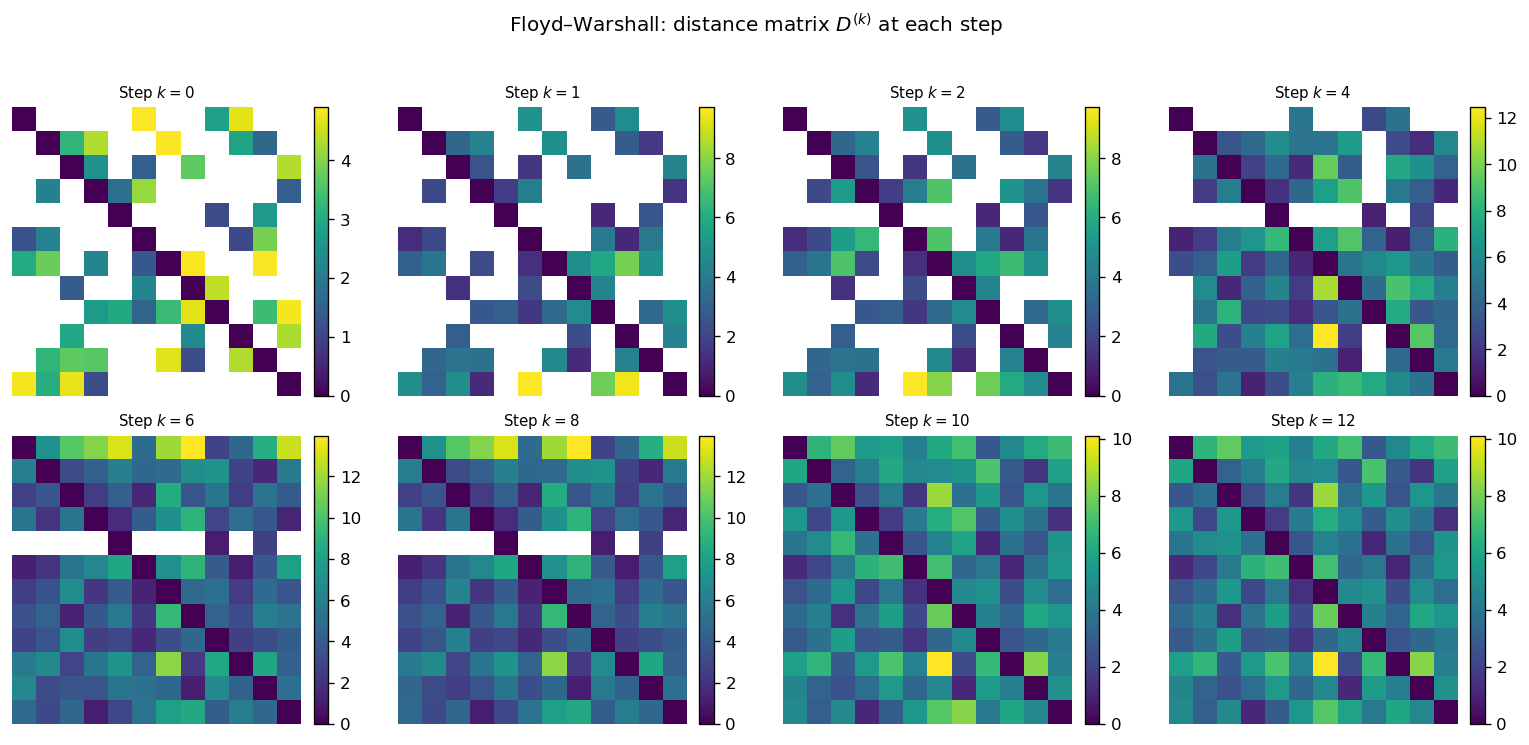

In [3]:
rng = np.random.default_rng(42)
n = 12

# Random sparse graph: each edge present with probability p, weight in [1,5]
p_edge = 0.4
W = np.full((n, n), np.inf)
np.fill_diagonal(W, 0.0)
for i in range(n):
    for j in range(n):
        if i != j and rng.random() < p_edge:
            W[i, j] = rng.uniform(1, 5)

# Run and record each step
D_steps = [W.copy()]
D = W.copy()
for k in range(n):
    D = np.minimum(D, D[:, k:k+1] + D[k:k+1, :])
    D_steps.append(D.copy())

# Display 8 snapshots
steps_disp = [0, 1, 2, 4, 6, 8, 10, 12]
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for ax, k in zip(axes.ravel(), steps_disp):
    Dk = D_steps[k]
    vis = np.where(np.isinf(Dk), np.nan, Dk)
    im = ax.imshow(vis, cmap='viridis', aspect='equal')
    ax.set_title(f'Step $k={k}$', fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('Floyd–Warshall: distance matrix $D^{(k)}$ at each step', y=1.02)
plt.tight_layout()
plt.show()

## Shortest-path tree from a source

Once the distance matrix $D$ is computed, we can visualize the shortest-path tree from any source vertex: the tree of all optimal paths from that source to every other vertex.

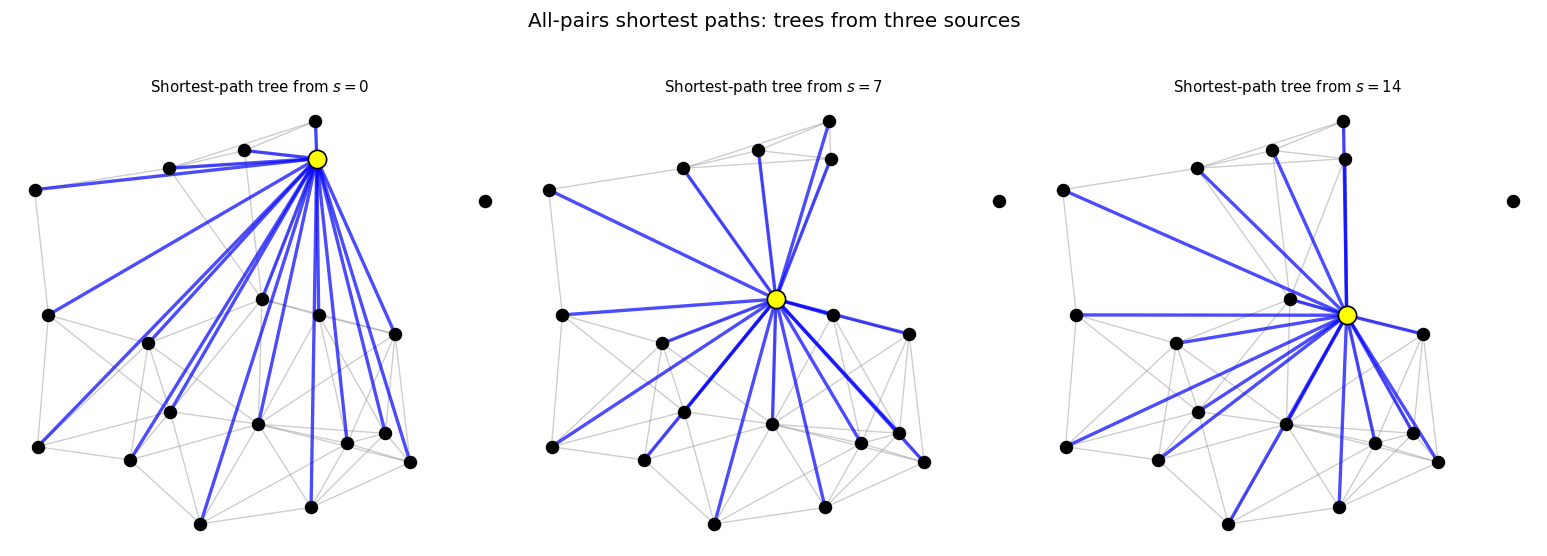

In [4]:
# Build a small random geometric graph for clean visualization
n_vis = 20
rng2 = np.random.default_rng(7)
pos = rng2.uniform(0, 1, (n_vis, 2))

# Connect pairs within distance threshold
thresh = 0.38
W_vis = np.full((n_vis, n_vis), np.inf)
np.fill_diagonal(W_vis, 0.0)
for i in range(n_vis):
    for j in range(i+1, n_vis):
        d = np.linalg.norm(pos[i] - pos[j])
        if d < thresh:
            W_vis[i, j] = d
            W_vis[j, i] = d

D_vis = floyd_warshall(W_vis)

# Predecessor matrix for path reconstruction
def pred_matrix(W):
    n = len(W)
    D = W.copy()
    P = np.where(np.isfinite(W), np.tile(np.arange(n), (n,1)).T, -1)
    np.fill_diagonal(P, -1)
    for k in range(n):
        better = D[:, k:k+1] + D[k:k+1, :] < D
        P[better] = P[np.nonzero(better)[0], k]
        D = np.minimum(D, D[:, k:k+1] + D[k:k+1, :])
    return D, P

D_vis2, P_vis = pred_matrix(W_vis)

def get_path(P, src, dst):
    if P[src, dst] == -1 and src != dst:
        return []
    path = [dst]
    while path[-1] != src:
        prev = P[src, path[-1]]
        if prev == -1:
            return []
        path.append(prev)
    return list(reversed(path))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, src in zip(axes, [0, 7, 14]):
    # draw all edges
    for i in range(n_vis):
        for j in range(i+1, n_vis):
            if np.isfinite(W_vis[i, j]):
                ax.plot([pos[i,0], pos[j,0]], [pos[i,1], pos[j,1]],
                        'gray', lw=0.8, alpha=0.4)
    # draw shortest-path tree
    for dst in range(n_vis):
        if dst == src: continue
        path = get_path(P_vis, src, dst)
        if len(path) >= 2:
            for a, b in zip(path[:-1], path[1:]):
                t = D_vis2[src, dst] / (D_vis2[src, :].max() + 1e-8)
                ax.plot([pos[a,0], pos[b,0]], [pos[a,1], pos[b,1]],
                        color=(t, 0, 1-t), lw=2.0, alpha=0.7)
    ax.scatter(*pos.T, s=50, c='k', zorder=5)
    ax.scatter(*pos[src], s=120, c='yellow', edgecolors='k', zorder=6)
    ax.set_title(f'Shortest-path tree from $s={src}$', fontsize=9)
    ax.axis('off')
fig.suptitle('All-pairs shortest paths: trees from three sources', y=1.02)
plt.tight_layout()
plt.show()

## Min-plus algebra and tropical semiring

The min-plus product $D = W^{\otimes n}$ (repeated $n$ times) gives the same result as Floyd–Warshall. Here we verify this and visualize the intermediate powers $W^{\otimes k}$, which encode the shortest paths using **at most $k$ hops**.

Max error FW vs min-plus power: 0.00e+00


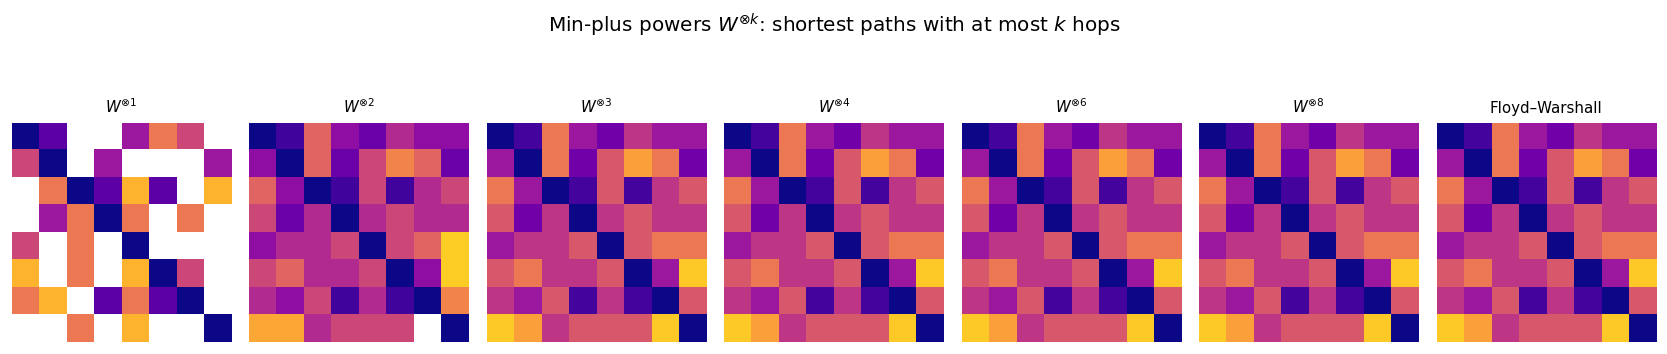

In [5]:
# Small graph for min-plus demonstration
n_mp = 8
rng3 = np.random.default_rng(3)
W_mp = np.full((n_mp, n_mp), np.inf)
np.fill_diagonal(W_mp, 0.0)
for i in range(n_mp):
    for j in range(n_mp):
        if i != j and rng3.random() < 0.5:
            W_mp[i, j] = rng3.integers(1, 6).astype(float)

D_fw = floyd_warshall(W_mp)

# Min-plus powers
powers = [1, 2, 3, 4, 6, n_mp]
fig, axes = plt.subplots(1, len(powers)+1, figsize=(14, 3))

for ax, k in zip(axes[:-1], powers):
    Dk = min_plus_power(W_mp, k)
    vis = np.where(np.isinf(Dk), np.nan, Dk)
    ax.imshow(vis, cmap='plasma', aspect='equal', vmin=0, vmax=np.nanmax(vis)+1)
    ax.set_title(f'$W^{{\\otimes {k}}}$', fontsize=9); ax.axis('off')

vis_fw = np.where(np.isinf(D_fw), np.nan, D_fw)
axes[-1].imshow(vis_fw, cmap='plasma', aspect='equal', vmin=0, vmax=np.nanmax(vis_fw)+1)
axes[-1].set_title('Floyd–Warshall', fontsize=9); axes[-1].axis('off')

print(f'Max error FW vs min-plus power: {np.nanmax(np.abs(D_fw - min_plus_power(W_mp, n_mp))):.2e}')
fig.suptitle('Min-plus powers $W^{\\otimes k}$: shortest paths with at most $k$ hops', y=1.05)
plt.tight_layout()
plt.show()

## Interactive: trace a shortest path

Pick a source and destination to trace the optimal path on the random geometric graph.

In [6]:
def show_path(source=0, dest=10):
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in range(n_vis):
        for j in range(i+1, n_vis):
            if np.isfinite(W_vis[i, j]):
                ax.plot([pos[i,0], pos[j,0]], [pos[i,1], pos[j,1]],
                        'gray', lw=0.8, alpha=0.4)
    path = get_path(P_vis, source, dest)
    if len(path) >= 2:
        for a, b in zip(path[:-1], path[1:]):
            ax.plot([pos[a,0], pos[b,0]], [pos[a,1], pos[b,1]],
                    'tomato', lw=3, zorder=4)
    ax.scatter(*pos.T, s=60, c='steelblue', zorder=5)
    ax.scatter(*pos[source], s=150, c='green', edgecolors='k', zorder=6, label='source')
    ax.scatter(*pos[dest],   s=150, c='red',   edgecolors='k', zorder=6, label='dest')
    d = D_vis2[source, dest]
    ax.set_title(f'Shortest path {source} → {dest},  distance = {d:.3f}')
    ax.legend(fontsize=9); ax.axis('off')
    plt.tight_layout(); plt.show()

interact(show_path,
         source=IntSlider(value=0, min=0, max=n_vis-1, step=1, description='source'),
         dest=IntSlider(value=10, min=0, max=n_vis-1, step=1, description='dest'));

interactive(children=(IntSlider(value=0, description='source', max=19), IntSlider(value=10, description='dest'…

## Bibliographical resources

- Floyd, R. W. (1962). Algorithm 97: Shortest path. *Communications of the ACM*, 5(6), 345.
- Warshall, S. (1962). A theorem on Boolean matrices. *Journal of the ACM*, 9(1), 11–12.
- Bellman, R. (1958). On a routing problem. *Quarterly of Applied Mathematics*, 16(1), 87–90.
- Cormen, T. H., Leiserson, C. E., Rivest, R. L. and Stein, C. (2009). *Introduction to Algorithms* (3rd ed.). MIT Press. Chapter 25.
- Cuninghame-Green, R. A. (1979). *Minimax Algebra*. Springer. (Tropical / min-plus semiring foundations.)